In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import plotly.graph_objects as go
import plotly.express as px

# Introduction to the Datasets
We analyze the data from an experiment that evaluates the effectiveness of a program that offers teachers in Italian middle schools the chance to participate in a training. The training is designed to help them promote inclusive practices in the classroom. The experiment was designed as a randomized control trial (RCT), however we will not enter the RCT-based analysis. Here, we will clean the data from this experiment and perform some basic analysis.


In [ ]:
# Load the first dataset. Here is the link to the dataset:
# https://drive.google.com/uc?id=1oE-3rt17bFW7fOzDIjwFSEMPTIV3NvcO

df = pd.read_csv("https://drive.google.com/uc?id=1oE-3rt17bFW7fOzDIjwFSEMPTIV3NvcO")

In [ ]:
# See what columns are there. Try to make sense of them.

df.columns
df.describe()

# Is there any column with strange values?
# Yes we have missing value and false entries

,school_id,grade,sex,nationality,grade_math_t1,grade_language_t1,grade_science_t1,grade_math_t2,grade_language_t2,grade_science_t2,treatment
count,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1508.000000,1507.000000,1508.000000,1510.000000
mean,457.321192,7.037086,1.203311,1.195364,6.653575,6.628136,6.642331,205.855164,139.605428,205.836261,0.501325
std,315.676789,0.817277,0.402595,0.396612,1.701152,1.713346,1.698250,4456.943949,3641.496348,4456.944784,0.500164
min,57.000000,6.000000,1.000000,1.000000,0.000000,0.993821,0.000000,0.000000,0.000000,0.000000,0.000000
25%,141.000000,6.000000,1.000000,1.000000,5.563173,5.530065,5.472154,5.635373,5.601699,5.676830,0.000000
50%,458.000000,7.000000,1.000000,1.000000,6.829838,6.775808,6.757819,7.105604,7.058270,7.024505,1.000000
75%,812.000000,8.000000,1.000000,1.000000,7.943985,7.852015,7.921141,8.386922,8.358125,8.406066,1.000000
max,946.000000,8.000000,2.000000,2.000000,10.000000,10.000000,10.000000,99999.000000,99999.000000,99999.000000,1.000000


### Student Dataset:
Contain administrative information on students’ characteristics and academic performance. The data are organized at the student level and contain the following variables:
- **school_id** : A variable that identifies in which school the student is enrolled.
- **grade**: A variable that identifies students’ grade.
- **class**: A variable that identifies students’ class. In our setting, students are enrolled in only one school-grade-class.
- **student_id** : A variable containing an unique identifier for students (their email address).
- **sex**: A variable that identifies students’ sex. 1 refers to female students and 2 to male students.
- **nationality**: A variable that identifies students’ nationality. 1 refers to students with Italian citizenship and 2 to foreign students.
- **grade_math_t1** : Students’ grade in math at period 1 (i.e. before the intervention)
- **grade_language_t1** : Students’ grade in language at period 1 (i.e. before the intervention)
- **grade_science_t1** : Students’ grade in science at period 1 (i.e. before the intervention)
- **grade_math_t2** : Students’ grade in math at period 2 (i.e. after the intervention)
- **grade_language_t2** : Students’ grade in language at period 2 (i.e. after the intervention)
- **grade_science_t2** : Students’ grade in science at period 2 (i.e. after the intervention)
- **treatment**: A variable indicating if the student was taught by a teacher who was assigned to the treatment group.

**Note**: The italian grade system grades students from 0 to 10.

In [ ]:
# Extract information about columns' datatype and shape.

df.shape
df.dtypes

school_id              int64
grade                  int64
class                 object
student_id            object
sex                    int64
nationality            int64
grade_math_t1        float64
grade_language_t1    float64
grade_science_t1     float64
grade_math_t2        float64
grade_language_t2    float64
grade_science_t2     float64
treatment              int64
date_of_birth         object
dtype: object

In [ ]:
# Rename all the grade columns such that the part "grade_" is removed from the column name.

df = df.rename(columns=lambda x: x.replace('grade_', ''))
# df = df.columns.str.replace('grade_', '')
# df = df.rename(columns=lambda x: x.replace("grade_", ""))
df.columns

Index(['school_id', 'grade', 'class', 'student_id', 'sex', 'nationality',
       'math_t1', 'language_t1', 'science_t1', 'math_t2', 'language_t2',
       'science_t2', 'treatment', 'date_of_birth'],
      dtype='object')

In [ ]:
# Are there duplicates?

df.nunique()
# df.loc[df["student_id"].duplicated(), "student_id"]

school_id          10
grade               3
class               4
student_id       1500
sex                 2
nationality         2
math_t1          1497
language_t1      1490
science_t1       1492
math_t2          1414
language_t2      1422
science_t2       1421
treatment           2
date_of_birth     824
dtype: int64

-------------------------------------------------------------------------
**Quiz**: Do you know how to compute the number of duplicates for each column?

In [ ]:
# df["count"] = df["student_id"].duplicated().sum()
df.apply(lambda col: col.duplicated().sum())

school_id        1500
grade            1507
class            1506
student_id         10
sex              1508
nationality      1508
math_t1            13
language_t1        20
science_t1         18
math_t2            95
language_t2        87
science_t2         88
treatment        1508
date_of_birth     686
dtype: int64

In [ ]:
# Handle the duplicates.

df = df.copy().drop_duplicates()

-----------------------------------------------------------------
### Exercise 1:
Write a function that iterates through certain columns and determines whether all the entries of those columns unique. Use the following template.

In [ ]:
def _unique_check(df: pd.DataFrame, cols: list) -> list:
    """Verifies that entries in the input columns are unique.

        Args:
          df: A DataFrame.
          cols: List of columns names to check.

        Returns:
          A list with the structure ["unique_check", "col", "PASSED"/"FAILED"].
    """
    result = []
    for col in cols:
        if df[col].is_unique:
            result.append(["unique_check", col, "PASSED"])
        else:
            result.append(["unique_check", col, "FAILED"])
    return result

result = _unique_check(df=df, cols=list(df.columns))
print(result)

[['unique_check', 'school_id', 'FAILED'], ['unique_check', 'grade', 'FAILED'], ['unique_check', 'class', 'FAILED'], ['unique_check', 'student_id', 'PASSED'], ['unique_check', 'sex', 'FAILED'], ['unique_check', 'nationality', 'FAILED'], ['unique_check', 'math_t1', 'FAILED'], ['unique_check', 'language_t1', 'FAILED'], ['unique_check', 'science_t1', 'FAILED'], ['unique_check', 'math_t2', 'FAILED'], ['unique_check', 'language_t2', 'FAILED'], ['unique_check', 'science_t2', 'FAILED'], ['unique_check', 'treatment', 'FAILED'], ['unique_check', 'date_of_birth', 'FAILED']]


-----------------------------------------------------------------------

In [ ]:
# What about null/missing values?

df.isna().sum()

school_id        0
grade            0
class            0
student_id       0
sex              0
nationality      0
math_t1          0
language_t1      0
science_t1       0
math_t2          2
language_t2      3
science_t2       2
treatment        0
date_of_birth    0
dtype: int64

--------------------------------------------------------------------
### Exercise 2:
Write a function that iterates through certain columns and determines whether they contain missing values or not. Use the following template

In [ ]:
def _missing_value_check(df: pd.DataFrame, cols: list) -> list:
    """Used to verify that the input column in the DataFrame does not contain missing values.

    Args:
        df: The DataFrame containing the data.
        cols: List of columns names to check.

    Returns:
        A list with the structure ["missing_value_check", "col", "PASSED"/"FAILED"] for each column.
    """
    result = []
    for col in cols:
        if df[col].isnull().any(): # df[col] = [1, 2, None, 8] --> [False, False, True, False]
            result.append(["missing_value_check", col, "FAILED"])
        else:
            result.append(["missing_value_check", col, "PASSED"])

    # for col in cols:
    #     # Your code
    #     if df[col].isna().sum()!=0: # df[col] = [1, 2, None, 8] --> [False, False, True, False]
    #       result.append(['missing_value_check', col, 'FAILED'])
    #     else:
    #       result.append(['missing_value_check', col, 'PASSED'])
    return result

result = _missing_value_check(df=df, cols=["student_id", "language_t1", "science_t2"])
print(result)

[['missing_value_check', 'student_id', 'PASSED'], ['missing_value_check', 'language_t1', 'PASSED'], ['missing_value_check', 'science_t2', 'FAILED']]


-------------------------------------------------------
### How to deal with the missing data?
In general, missing values could be random, or related to certain aspect of the data. **An example of the latter**: in the income surveys, individual with higher income are less willing to report their income.

General ways to handle missing values:

- remove the corresponding row or column
- imputation - mean, median, mode, regression etc.
- Flagging - using a flag to indicate the missing value

**BUT** we also need to identify the values that are missing but not explicitly designated by **null**, **NaN** or **None**. In the case of our dataset, the grades greater than 10.

**Attention**: Is there any other case/column to be considered?


-------------------------------------------------------------------------------
### Exercise 3:
We know from the properties of the dataset that the student grades cannot be greater than 10. Write a function to check if the values of the grade columns are less than 10 or not.

In [ ]:
def _upper_limit_check(df: pd.DataFrame, cols: list, limit: float) -> list:
    """Verifies that entries in the input columns are less than a certain limit.

    Args:
        df: The DataFrame containing the data.
        cols: List of column names to check.
        limit: Upper limit for the values.

    Returns:
        A list with the structure ["upper_limit_check", "col", "PASSED"/"FAILED"] for each column.
    """
    result = []
    for col in cols:
        if (df[col] <= limit).all():
          result.append(["upper_limit_check", col, "PASSED"])
        else:
          # df_limit = df.loc[(df[col] > limit), col]
          # print(df_limit)
          result.append(["upper_limit_check", col, "FAILED"])
    return result

result = _upper_limit_check(df=df, cols=["language_t1", "science_t2", "school_id"], limit=10.0)
print(result)

[['upper_limit_check', 'language_t1', 'PASSED'], ['upper_limit_check', 'science_t2', 'FAILED'], ['upper_limit_check', 'school_id', 'FAILED']]


-----------------------------------------------------------------
Now that you have checked the values, try to handle those greater than 10.

In [ ]:
# Replace the values greater than 10 in the grade columns with np.nan.
df.loc[:, "math_t1":"science_t2"] = df.loc[:, "math_t1":"science_t2"].apply(
    lambda x: np.where(x > 10, np.nan, x)
)

# df.loc[:, "math_t1":"science_t2"] = np.where(
    # df.loc[:, "math_t1":"science_t2"]>10, np.nan, df.loc[:, "math_t1":"science_t2"]
# )
df.isna().sum()

school_id        0
grade            0
class            0
student_id       0
sex              0
nationality      0
math_t1          0
language_t1      0
science_t1       0
math_t2          5
language_t2      5
science_t2       5
treatment        0
date_of_birth    0
dtype: int64

In [ ]:
# Handle the missing values.
col = "math_t2"
col_fillna = "math_t2_fillna"
df["math_t2_fillna"] = df.groupby(by=["school_id", "grade", "class"])["math_t2"].transform("mean")
print(df["math_t2"][df["math_t2"].isna()])
# print(df[df["math_t2"].isna(), "math_t2"])
print(df["math_t2_fillna"][df["math_t2"].isna()])
df.loc[df["math_t2"].isna(), "math_t2"] = df.loc[df["math_t2"].isna(), "math_t2_fillna"]
df = df.drop(columns=["math_t2_fillna"], axis=1)

col = "language_t2"
col_fillna = "language_t2_fillna"
df["language_t2_fillna"] = df.groupby(by=["school_id", "grade", "class"])["language_t2"].transform("mean")
print(df["language_t2"][df["language_t2"].isna()])
print(df["language_t2_fillna"][df["language_t2"].isna()])
df.loc[df["language_t2"].isna(), "language_t2"] = df.loc[df["language_t2"].isna(), "language_t2_fillna"]
df = df.drop(columns=["language_t2_fillna"], axis=1)

df["science_t2_fillna"] = df.groupby(by=["school_id", "grade", "class"])["science_t2"].transform("mean")
print(df["science_t2"][df["science_t2"].isna()])
print(df["science_t2_fillna"][df["science_t2"].isna()])
df.loc[df["science_t2"].isna(), "science_t2"] = df.loc[df["science_t2"].isna(), "science_t2_fillna"]
df = df.drop(columns=["science_t2_fillna"], axis=1)

96     NaN
279    NaN
404    NaN
848    NaN
1284   NaN
Name: math_t2, dtype: float64
96      7.404859
279     7.275353
404     8.047475
848     6.594183
1284    6.826758
Name: math_t2_fillna, dtype: float64
225    NaN
371    NaN
566    NaN
1202   NaN
1440   NaN
Name: language_t2, dtype: float64
225     7.505878
371     7.846060
566     6.982583
1202    6.226394
1440    6.375402
Name: language_t2_fillna, dtype: float64
118    NaN
153    NaN
169    NaN
1060   NaN
1178   NaN
Name: science_t2, dtype: float64
118     6.284261
153     6.620376
169     6.443465
1060    5.889444
1178    6.982939
Name: science_t2_fillna, dtype: float64


----------------------------------------------------------
**Question**: How should we address the *date_of_birth* column?

--------------------------------------------------------------
### Exercise 4:
Write a function that checks if all the date formats of the a date column, e.g. *date_of_birth* is correct.

In [ ]:
def _date_check(df: pd.DataFrame, col: str) -> list:
    """Used to verify that the column in the input DataFrame has a correct format for converting to datetime.

    Args:
        df: DataFrame containing input data.
        col: Name of column which is checked.

    Returns:
        A list with the structure ["_date_check", "col", "PASSED"/"FAILED"] for each column.
    """
    results = []
    try:
        # Convert the column to datetime and see if any error raised, if yes,
        # there is a problem with the format
        pd.to_datetime(df[col], errors='raise')
        results.append(["date_check", col, "PASSED"])
    except ValueError:
        results.append(["date_check", col, "FAILED"])

    return results

result = _date_check(df=df, col="date_of_birth")
print(result)

[['_date_check', 'date_of_birth', 'FAILED']]


**Challenge**: Is there anyway to identify the non-conforming entries without looking for them in the dataset.

----------------------------------
##Exercise 5 (in class):
- Import the survey_data.csv using the link:
https://drive.google.com/uc?id=1A0B4z0Dohs8gfikJyh4p_FEUWyPD2U9f
- Repeat all the above steps.
- For each survey question i (variables q1 to q8), create a numeric variable called qib (i.e., q1b to q8b) that assigns a numeric value to each qualitative answer.
- Merge the two datasets. **Hint**: Think about the column that is present in both datasets and is a primary key.  

In [ ]:
df_survey = pd.read_csv("https://drive.google.com/uc?id=1A0B4z0Dohs8gfikJyh4p_FEUWyPD2U9f")

In [ ]:
# See what columns are there. Try to make sense of them.

df_survey.head(5)

,student_id,school_id,grade,class,q1,q2,q3,q4,q5,q6,q7,q8,complete_survey
0,0hIoq@cunb.edu,812,8,A,Very much,Slightly,Somewhat,Disagree,Strongly agree,Agree,Strongly disagree,Enroll in an university,1
1,0JGtI@cunb.edu,458,8,A,Slightly,Somewhat,Much,Neutral,Disagree,Agree,Strongly disagree,I don't know,1
2,0PATX@cunb.edu,946,8,C,Much,Somewhat,Very much,Strongly agree,Strongly agree,Neutral,Strongly disagree,Work after finishing school,1
3,0PYm6@cunb.edu,812,7,B,Much,Much,Much,Agree,Disagree,Agree,Strongly disagree,Enroll in an university,1
4,0WFMz@cunb.edu,812,8,D,Slightly,Very much,Not at all,Neutral,Disagree,Strongly agree,Disagree,I don't know,1


#### Survey Dataset
Contain information from a survey that was sent to students before the intervention. Participation in the survey was optional. These data are organized at the student level and contain the following variables:
- **school_id** : A variable that identifies in which school the student is enrolled.
- **grade**: A variable that identifies students’ grade.
- **class**: A variable that identifies students’ class. In our setting, students are enrolled in only
one schoolgrade- class.
- **student_id** : A variable containing an unique identifier for students (their email address).
- **q1** : Survey question 1 ”Would you say you enjoy studying mathematics?”.
- **q2** : Survey question 2 ”Would you say you enjoy studying Language?”.
- **q3** : Survey question 3 ”Would you say you enjoy studying science?”.
- **q4** : Survey question 4 ”Would you agree with the following statement: I believe my teacher
cares about my learning.”.
- **q5** : Survey question 5 ”Would you agree with the following statement: I believe my teacher
cares about my well-being.”.
- **q6** : Survey question 6 ”Would you agree with the following statement: I believe my teacher
helps create an inclusive environment in the classroom.”.
- **q7** : Survey question 7 ”Would you agree with the following statement: I believe my school
provides adequate resources for underrepresented students.”.
- **q8** : Survey question 8 ”What are your plans for the future?”.



In [ ]:
# Extract information about columns' datatype and shape.

df_survey.shape
df_survey.dtypes

student_id         object
school_id           int64
grade               int64
class              object
q1                 object
q2                 object
q3                 object
q4                 object
q5                 object
q6                 object
q7                 object
q8                 object
complete_survey     int64
dtype: object

In [ ]:
# Are there duplicates?

df_survey.nunique()

num_duplicates = df_survey.apply(lambda x: x.duplicated().sum())
print(num_duplicates)

student_id          10
school_id          500
grade              507
class              506
q1                 504
q2                 504
q3                 504
q4                 504
q5                 504
q6                 504
q7                 504
q8                 503
complete_survey    508
dtype: int64


In [ ]:
# what about null/missing values?

df_survey.isna().sum()

student_id         0
school_id          0
grade              0
class              0
q1                 4
q2                 4
q3                 4
q4                 4
q5                 4
q6                 4
q7                 4
q8                 4
complete_survey    0
dtype: int64

In [ ]:
# Handle the duplicates and the missing values.
df_survey.loc[:, "q1": "q8"] = df_survey.loc[:, "q1": "q8"].apply(lambda x: np.where(x.isna(), x.mode(), x))
df_survey.isna().sum()


student_id         0
school_id          0
grade              0
class              0
q1                 0
q2                 0
q3                 0
q4                 0
q5                 0
q6                 0
q7                 0
q8                 0
complete_survey    0
dtype: int64

### Join:
How can we join this data with the previous one?

**Remember**:

# Inner Join
![left join](https://learn.microsoft.com/en-us/power-query/media/merge-queries-inner/inner-join-operation.png)

# Left Join
![left join](https://docs.microsoft.com/de-de/power-query/images/left-outer-join-operation.png)

In [ ]:
# Merge the survey dataset with the previous one
df_tot = df.merge(df_survey, how="left", on=["student_id", "school_id", "grade", "class"])
df_tot.columns
df_tot.shape

(1502, 23)

In [ ]:
# Merge the survey dataset with the previous one
df_tot = df.merge(df_survey, how="inner", on=["student_id"])
df_tot.columns
df_tot.shape

(44, 26)

------------------------------------------------------------
### Data Analysis:
Hereafter, we perform calculations on the data to perform basic analysis about the experiment.

In [ ]:
# Create a variable for the average grade of each student in each period, i.e. avg_t1 and avg_t2.

df["avg_t1"] = df.loc[:, "math_t1":"science_t1"].mean(axis=1)
df["avg_t2"] = df.loc[:, "math_t2":"science_t2"].mean(axis=1)
df.columns

Index(['school_id', 'grade', 'class', 'student_id', 'sex', 'nationality',
       'math_t1', 'language_t1', 'science_t1', 'math_t2', 'language_t2',
       'science_t2', 'treatment', 'date_of_birth', 'avg_t1', 'avg_t2'],
      dtype='object')

----------------------------------
###Statistics Challenge 😊:
Based on the dataset, what is the probability of a student having an average grade in period 1 greater than 7 if they belong to the *school_id=57*.

**Hint**: Do you know conditional probability?😎
$$P(A|B) = \frac{P(A, B)}{P(B)}$$

Now! if I tell you a student's averge grade in period 1 is greater than 7, what is the probability that it belongs to the *school_id=57*?.   

----------------------------------

**Question**: How can we compare the collective performance of the students in the two periods? Is there anyway to break down our anlysis into different student groups?

In [ ]:
# Create a variable which indicates the quantile each student's average grade in period 1 belongs to, i.e. avg_t1_q (assume 4 quantiles).

df['avg_t1_q'] = pd.qcut(df['avg_t1'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

**Question**: How can we use the variables defined above to perform a more in-depth analysis?

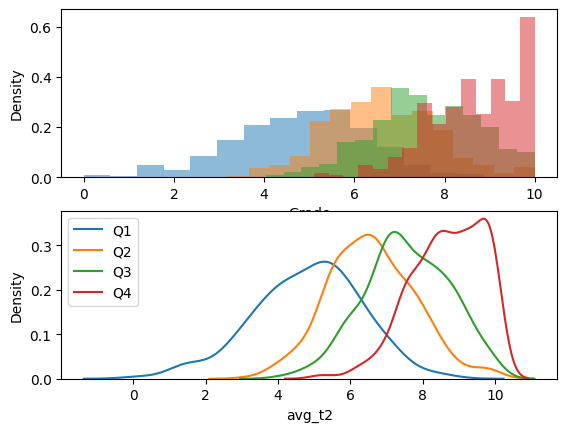

In [ ]:
# Plot the distribution of each quantile for periods 1 and 2.

# Histogram plot
fig, ax = plt.subplots(2, 1)
ax[0].hist(df[df['avg_t1_q'] == "Q1"]["avg_t2"], bins=15, alpha=0.5, density=True)
ax[0].hist(df[df['avg_t1_q'] == "Q2"]["avg_t2"], bins=15, alpha=0.5, density=True)
ax[0].hist(df[df['avg_t1_q'] == "Q3"]["avg_t2"], bins=15, alpha=0.5, density=True)
ax[0].hist(df[df['avg_t1_q'] == "Q4"]["avg_t2"], bins=15, alpha=0.5, density=True)
ax[0].set(ylabel="Density", xlabel="Grade")

# Kernel Density Estimate (KDE plot)
sb.kdeplot(df[df['avg_t1_q'] == "Q1"]["avg_t2"])
sb.kdeplot(df[df['avg_t1_q'] == "Q2"]["avg_t2"])
sb.kdeplot(df[df['avg_t1_q'] == "Q3"]["avg_t2"])
sb.kdeplot(df[df['avg_t1_q'] == "Q4"]["avg_t2"])

plt.legend(["Q1", "Q2", "Q3", "Q4"])
plt.show()

**Question**: What can you see from the distributions?

-------------------------------------------------------------------
### Exercise 6:
Plot the distributions of all the quintiles of period one and their corresponding distributions in period 2 in one **interactive plot**. Compare the results and write down your thoughts as a comment in your code.

**Hint**: you can use the *plotly* library.

In [ ]:

fig = go.Figure()
for quartile in ['Q1', 'Q2', 'Q3', 'Q4']:
    data_quartile = df[df['avg_t1_q'] == quartile]['avg_t1']
    fig.add_trace(go.Histogram(x=data_quartile, nbinsx=15, opacity=0.5, histnorm='density', name=quartile+"-t1"))
    data_quartile = df[df['avg_t1_q'] == quartile]['avg_t2']
    fig.add_trace(go.Histogram(x=data_quartile, nbinsx=15, opacity=0.5, histnorm='density', name=quartile+"-t2"))

fig.update_layout(xaxis_title='Average T2', yaxis_title='Density', title='Histogram of Average T2 by Quartile')
fig.show()

-------------------------------------------------------------------
### Exercise 7 (Optional):
Plot (in an interactive plot or normal one) the distributions in Exercise 2 for the first quintiles for 4 cases, 1) period 1, qurtile 1, and treatment=0, 2) period 1, qurtile 1, and treatment=1, 3) period 2, qurtile 1, and treatment=0, and 4) period 2, qurtile 1, and treatment=1. Compare the results and write down your thoughts as a comment in your code.

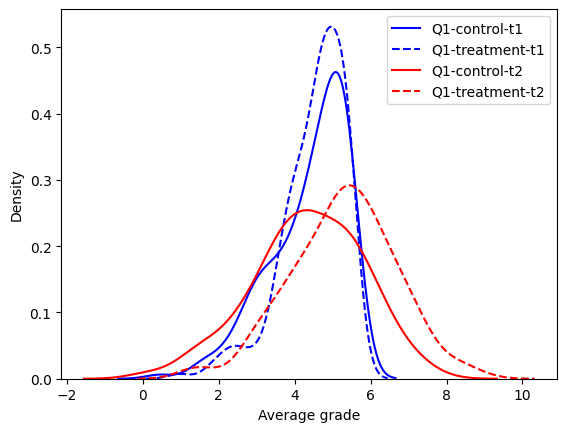

In [ ]:
fig, ax = plt.subplots(1, 1)

quartile = "Q1"

# Kernel Density Estimate (KDE plot)
sb.kdeplot(df[(df['avg_t1_q'] == quartile)&(df['treatment'] == 0)]["avg_t1"], color="b")
sb.kdeplot(df[(df['avg_t1_q'] == quartile)&(df['treatment'] == 1)]["avg_t1"], color="b", linestyle="dashed")
sb.kdeplot(df[(df['avg_t1_q'] == quartile)&(df['treatment'] == 0)]["avg_t2"], color="r")
sb.kdeplot(df[(df['avg_t1_q'] == quartile)&(df['treatment'] == 1)]["avg_t2"], color="r", linestyle="dashed")

plt.legend([f"{quartile}-control-t1", f"{quartile}-treatment-t1", f"{quartile}-control-t2", f"{quartile}-treatment-t2"])
plt.xlabel('Average grade')
plt.ylabel('Density')
plt.show()

-------------------------------------------------------------------------
### Exercise 8 (data cleaning using object-oriented programming - optional):
Assume that the following table is given to you. We call it **coldef table** (column definition table), describing what checks must be run for each column to ensure that the entries are clean. 0 (or empty cell) indicates irrelvence of the property for the column while 1 denotes that the check must be run for the column in question.

 column name | missing_value_check | unique_check | numeric | upper_limit | date
 :- | -: | :-: |  :-: | :-: | :-:
  student_id | 1 | 1 |  | |
  math_t1 | 1 | 0 | 1 | 10 | |
  math_t2 | 1 | 0 | 1 | 10 | |
  date_of_birth | | | | | %Y-%d-%m

  #### Tasks:
  1. Define a new dataframe which consists of only the columns in the above table, i.e., a slice of the originial dataframe.
  2. Use the following object-oriented programming structure to check whether all the columns pass the checks mentioned in the table. A part of the code is written to help you figure out the rest.

In [ ]:
coldef = pd.DataFrame(
    {
        "column_name": ["student_id", "math_t1", "math_t2", "date_of_birth"],
        "missing_value_check": [1, 1, 1, np.nan],
        "unique_check": [1, 0, 0, np.nan],
        "numeric": [0, 1, 1, np.nan],
        "upper_limit": [np.nan, 10, 10, np.nan],
        "date": [None, None, None, "%Y-%m-%d"],
    }
)
data = df[["student_id", "math_t1", "math_t2", "date_of_birth"]]

class ColdefCheck:
  def __init__(self, data: pd.DataFrame, coldef: pd.DataFrame):
    self.coldef = coldef
    self.data = data

  def execute_coldef_checks(self):
    """Used to execute the different coldef checks and generate an overview of the results.

        Returns:
            A list of all results.
    """
    results = []
    results += self._missing_value_check()
    results += self._unique_check()
    results += self._numeric_check()
    results += self._upper_limit_check()
    results += self._date_check()
    return results

  def _missing_value_check(self) -> list:
    """Used to verify that the input column in the DataFrame does not contain missing values.

        Returns:
            A list with the structure ["missing_value_check", "col", "PASSED"/"FAILED"].
    """
    result = []
    for col in self.coldef.loc[self.coldef["missing_value_check"]==1, "column_name"]:
        if df[col].isnull().any(): # df[col] = [1, 2, None, 8] --> [False, False, True, False]
            result.append(["missing_value_check", col, "FAILED"])
        else:
            result.append(["missing_value_check", col, "PASSED"])

    return result

  def _unique_check(self) -> list:
    """Verifies that entries in the input columns are unique.

        Returns:
            A list with the structure ["unique_check", "col", "PASSED"/"FAILED"].
    """
    result = []
    for col in self.coldef.loc[self.coldef["unique_check"]==1, "column_name"]:
        if df[col].is_unique:
            result.append(["unique_check", col, "PASSED"])
        else:
            result.append(["unique_check", col, "FAILED"])
    return result

  def _numeric_check(self) -> list:
    """Verifies that the columns in the input DataFrame has a numeric ``dtype``.

        Returns:
            A list with the structure ["numeric_check",  "col", "PASSED"/"FAILED"].
    """
    result = []
    for col in self.coldef.loc[self.coldef["numeric"] == 1, "column_name"]:
      if self.data[col].dtype in ["int", "float"]:
        result.append(["numeric_check", col,  "PASSED"])
      else:
        result.append(["numeric_check", col, "FAILED"])
    return result

  def _upper_limit_check(self) -> list:
    """Verifies that entries in the input columns are less than a certain limit.

        Returns:
            A list with the structure ["upper_limit_check", "col", "PASSED"/"FAILED"].
    """
    result = []
    for col in self.coldef.loc[self.coldef["upper_limit"] > 0, "column_name"]:
      if (df[col] <= self.coldef.loc[self.coldef["column_name"]==col, "upper_limit"].iloc[0]).all():
        result.append(["upper_limit_check", col, "PASSED"])
      else:
        # df_limit = df.loc[(df[col] > limit), col]
        # print(df_limit)
        result.append(["upper_limit_check", col, "FAILED"])
    return result

  def _date_check(self) -> list:
    """Used to verify that the column in the input DataFrame has a correct format for converting to datetime.

    Args:
        df: DataFrame containing input data.
        col: Name of column which is checked.

    Returns:
        A list with the structure ["_date_check", "col", "PASSED"/"FAILED"] for each column.
    """
    results = []
    for col in self.coldef.loc[self.coldef["date"].notna(), "column_name"]:
      try:
          # Convert the column to datetime and see if any error raised, if yes,
          # there is a problem with the format
          date_format = self.coldef.loc[self.coldef["column_name"]==col, "date"].iloc[0]
          pd.to_datetime(df["date_of_birth"], format=date_format, errors="raise")
          results.append(["date_check", col, "PASSED"])
          # Your code
      except ValueError:
          results.append(["date_check", col, "FAILED"])

    return results

# We define an instance of our class (my version of the blueprint :-D)
my_dataset = ColdefCheck(data=data, coldef=coldef)

# To access any variable of function in my version of the class, I can use the
# my_version_of_class.variable or my_version_of_class.function
results = my_dataset.execute_coldef_checks()
for result in results:
  print(result)


['missing_value_check', 'student_id', 'PASSED']
['missing_value_check', 'math_t1', 'PASSED']
['missing_value_check', 'math_t2', 'PASSED']
['unique_check', 'student_id', 'PASSED']
['numeric_check', 'math_t1', 'PASSED']
['numeric_check', 'math_t2', 'PASSED']
['upper_limit_check', 'math_t1', 'PASSED']
['upper_limit_check', 'math_t2', 'PASSED']
['date_check', 'date_of_birth', 'FAILED']
